In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc
from scripts.partial_sc import partial_sc


In [2]:
widthD = 10
widthF = 1
widthP = 40

X, Y = widthD+widthF+widthP, 200
lattice = Lattice(X, Y)

t = 1
temp = 0.001

muD = 0.0 * t
muP = 1.8 * t
muF = 1.4 * t
mu = np.zeros(lattice.X)
mu[:widthD] = muD
mu[widthD:widthD + widthF] = muF
mu[widthD + widthF:] = muP

h0 = 1.8 * t
h = np.zeros_like(mu)
h[widthD:widthD + widthF] = h0

U = None

V0 = 0
V = V0 * np.ones(lattice.X)
V[widthD:] = 0
V[widthD-1] = V0/2

F_dwave = 0

V_prime0 = 2 * t
V_prime = V_prime0 * np.ones(lattice.X)
V_prime[:widthF+widthD] = 0
V_prime[widthF+widthD] = V_prime0/2

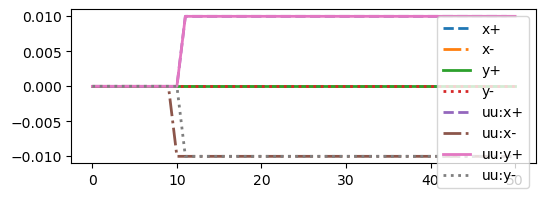

In [3]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[F_dwave, F_dwave, -F_dwave, -F_dwave],
                Fuu_init=[0.01, -0.01, 0.01j, -0.01j],
                Fdd_init=[0.01, -0.01, 0.01j, -0.01j],
                hx=h)

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(H.F0, label="F0")
if V is not None:
    plt.plot(np.real(H.F_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.real(H.F_xmin), label="x-", linestyle='-.', lw=2)
    plt.plot(np.real(H.F_yplus), label="y+", linestyle='-', lw=2)
    plt.plot(np.real(H.F_ymin), label="y-", linestyle=':', lw=2)
if V_prime is not None:
    plt.plot(np.real(H.Fuu_xplus), label="uu:x+", linestyle='--', lw=2)
    plt.plot(np.real(H.Fuu_xmin), label="uu:x-", linestyle='-.', lw=2)
    plt.plot(np.imag(H.Fuu_yplus), label="uu:y+", linestyle='-', lw=2)
    plt.plot(np.imag(H.Fuu_ymin), label="uu:y-", linestyle=':', lw=2)
plt.legend()

In [4]:
fixed_sites = V > 0
fixed_syms = ["F0", "F_xplus", "F_xmin", "F_yplus", "F_ymin"]
partial_sc(H, temperature=temp, 
            fixed_sites=fixed_sites, fixed_syms=fixed_syms, 
            atol=1e-6, rtol=1e-3, maxiter=10000, mixing=0.6)

F0 = H.F0
F, Fuu, Fdd = H.get_correlations()

Converged after 256 iterations


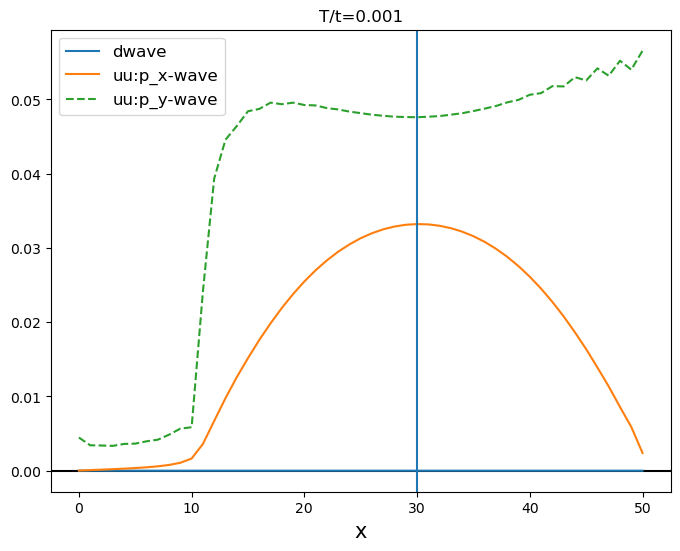

In [7]:
x = np.arange(0, widthD + widthF + widthP)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"T/t={temp}")
axs.axhline(0, color = 'black')

axs.plot(x, np.real(F.dwave), label="dwave")
axs.plot(x, np.real(Fuu.px), label="uu:p_x-wave")
axs.plot(x, np.imag(Fuu.py), "--", label="uu:p_y-wave")
axs.set_xlabel("x", fontsize=15)
# axs.set_xlim(20, 45)
# axs.set_ylim(0, 0.3)
axs.axvline(x[int(widthD+widthF+widthP/2)-1])
axs.legend(fontsize=12, loc="best")
plt.show()
